**DS5216 Artificial Intelligence: Programming Assignment II: DTS2433: R. D. Y. vimukthi**

**Notebook 3: Player Keypoint Detection**


 **Instructions:**

*   Please upload the cricket player images folder for player keypoint detection and change the path in "source" in code cell 5.
*   Please ensure best YOLOv8 model for player detection is uploaded at "content/runs/pose/predict", if you are predicting keypoints on top of detected players (no need if the player detection is conducted from the scratch along with keypoint detection)
*   Ensure that Dependencies are installed, and libraries are imported

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


**Using the pre-trained YOLOv8 Pose model**

In [4]:
from ultralytics import YOLO
# Load pretrained pose model
model = YOLO("yolov8n-pose.pt")

**Running Pose Detection on Cricket Images**

In [5]:
results = model.predict(
    source="/content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images",
    save=True,
    conf=0.3
)


image 1/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket10_mp4-0003_jpg.rf.5b5aa1b09aec697ddfe259e6ec8a58ce.jpg: 640x640 (no detections), 27.7ms
image 2/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket10_mp4-0015_jpg.rf.cc0f1fea5970311ba2ee51b50b20a44f.jpg: 640x640 (no detections), 15.2ms
image 3/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket10_mp4-0021_jpg.rf.b49d715ef1ea6cfbdc82e29ed467d650.jpg: 640x640 (no detections), 23.2ms
image 4/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket10_mp4-0022_jpg.rf.414accaf698faf00fed7b6fbe1141ecd.jpg: 640x640 (no detections), 8.2ms
image 5/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket1_mp4-0022_jpg.rf.3d97336c79afd0732db86aff15ae8d89.jpg: 640x640 4 persons, 8.3ms
ima

**Improving the model by applying transfer learning with COCOpose dataset**

Option A: Running pose detection on player crops

In [6]:
player_model = YOLO("runs/pose/best.pt")
pose_model = YOLO("yolov8n-pose.pt")
#player_results = player_model.predict(source="/content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images", save=True)

In [7]:
import os
image_folder = "/content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images"
image_files = os.listdir(image_folder)

In [8]:
import cv2
output_dir = "/content/output_option_A"
os.makedirs(output_dir, exist_ok=True)

for img_name in image_files:
    img_path = os.path.join(image_folder, img_name)
    img = cv2.imread(img_path)

    # 1. Detect players
    det_results = player_model.predict(img_path, conf=0.3)

    boxes = det_results[0].boxes.xyxy.cpu().numpy()

    # 2. Process each player
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        crop = img[y1:y2, x1:x2]

        # 3. Pose estimation on crop
        pose_results = pose_model.predict(crop, verbose=False)

        # Check if keypoints were detected and if the keypoint array is not empty
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints.xy) > 0:
            kpts = pose_results[0].keypoints.xy.cpu().numpy()[0]

            # draw skeleton points back on original image
            for kp in kpts:
                cx = int(kp[0]) + x1
                cy = int(kp[1]) + y1
                cv2.circle(img, (cx, cy), 3, (0, 0, 255), -1)

        # draw bbox
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # 4. Save output
    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, img)


image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket1_mp4-0027_jpg.rf.e1035e4d850986367668afe594493d86.jpg: 640x640 (no detections), 7.9ms
Speed: 3.9ms preprocess, 7.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket7_mp4-0004_jpg.rf.180c1ac8080fa64d5126b7df50d726aa.jpg: 640x640 4 players, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket1_mp4-0022_jpg.rf.3d97336c79afd0732db86aff15ae8d89.jpg: 640x640 (no detections), 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket10_mp4-00

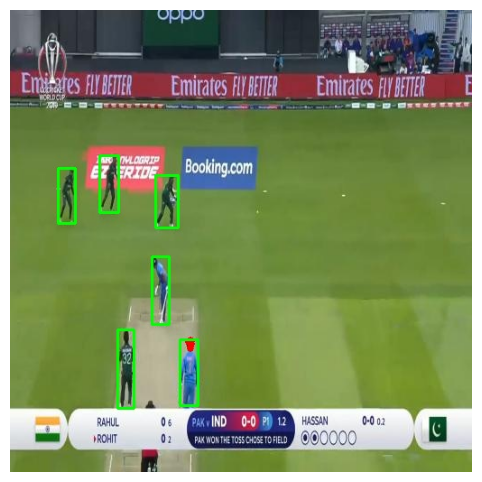

In [9]:
import matplotlib.pyplot as plt

output_dir = "/content/output_option_A" # Corrected output directory
sample = os.listdir(output_dir)[0]
img = cv2.imread(os.path.join(output_dir, sample))
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Option B: Loading YOLO labels

In [10]:
label_folder = "/content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/labels"

In [11]:
def load_yolo_boxes(label_path, img_w, img_h):
    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        cls, x, y, w, h = map(float, parts)

        # convert YOLO → pixel coords
        x1 = int((x - w/2) * img_w)
        y1 = int((y - h/2) * img_h)
        x2 = int((x + w/2) * img_w)
        y2 = int((y + h/2) * img_h)

        boxes.append((x1, y1, x2, y2))

    return boxes

In [12]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye", "right_eye",
    "left_ear", "right_ear",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle"
]

In [13]:
output_dir = "/content/output_option_B"
os.makedirs(output_dir, exist_ok=True)

In [14]:
import cv2
import os

def load_yolo_boxes(label_path, img_w, img_h):
    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        # Take only the first 5 values (class, x, y, w, h) for bounding box
        if len(parts) >= 5:
            cls, x, y, w, h = map(float, parts[:5])

            # convert YOLO → pixel coords
            x1 = int((x - w/2) * img_w)
            y1 = int((y - h/2) * img_h)
            x2 = int((x + w/2) * img_w)
            y2 = int((y + h/2) * img_h)

            boxes.append((x1, y1, x2, y2))

    return boxes

for img_name in image_files:
    img_path = os.path.join(image_folder, img_name)
    label_path = os.path.join(label_folder, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Load boxes from labels or fallback to model
    boxes = load_yolo_boxes(label_path, w, h)

    if len(boxes) == 0:
        det_results = player_model.predict(img_path, conf=0.3)
        # Ensure we convert to list of tuples for consistency if det_results is not empty
        if det_results[0].boxes is not None and len(det_results[0].boxes.xyxy) > 0:
            boxes = det_results[0].boxes.xyxy.cpu().numpy().tolist()
        else:
            boxes = [] # No detections even with fallback

    # Process each player
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        # Clamp coordinates to image boundaries
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        # Ensure valid bounding box dimensions (width and height > 0)
        if x2 <= x1 or y2 <= y1:
            # If the box is invalid, skip this iteration
            continue

        crop = img[y1:y2, x1:x2]

        pose_results = pose_model.predict(crop, verbose=False)

        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints.xy) > 0:
            kpts = pose_results[0].keypoints.xy.cpu().numpy()[0]

            # draw skeleton + labels
            for i, kp in enumerate(kpts):
                cx = int(kp[0]) + x1
                cy = int(kp[1]) + y1

                # draw point
                cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

                # draw label (KEY IMPROVEMENT)
                if i < len(KEYPOINT_NAMES):
                    label = KEYPOINT_NAMES[i]
                    cv2.putText(
                        img,
                        label,
                        (cx + 3, cy - 3),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.4,
                        (255, 255, 0),
                        1
                    )

        # draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # SAVE OUTPUT IMAGE
    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, img)

print("✅ Processing complete. Check:", output_dir)


image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket1_mp4-0027_jpg.rf.e1035e4d850986367668afe594493d86.jpg: 640x640 (no detections), 7.3ms
Speed: 2.7ms preprocess, 7.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket1_mp4-0022_jpg.rf.3d97336c79afd0732db86aff15ae8d89.jpg: 640x640 (no detections), 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket8_mp4-0028_jpg.rf.0bfd0b71894322f5b3a33890e842be13.jpg: 640x640 (no detections), 7.2ms
Speed: 2.9ms preprocess, 7.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images/cricket8_m

Total saved images: 31


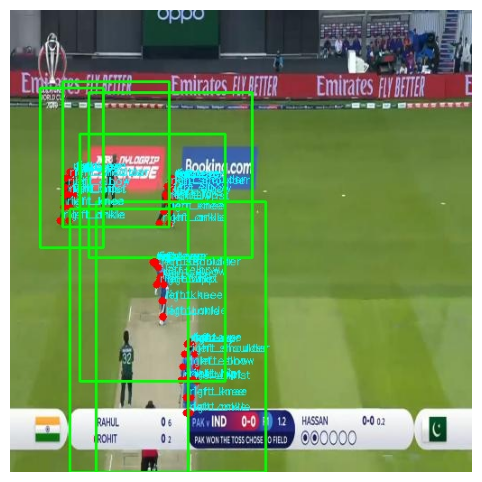

In [15]:
import glob

saved_images = glob.glob("/content/output_option_B/*.jpg")

print("Total saved images:", len(saved_images))

img = cv2.imread(saved_images[0])
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
import numpy as np
from ultralytics import YOLO
import os
import cv2

pose_model = YOLO("yolov8n-pose.pt")

image_folder = "/content/drive/MyDrive/DS5216 AI Programming Assignment/player-keypoint-detection/test/images"
image_files = os.listdir(image_folder)

keypoint_counts = []
confidence_scores = []

for img_name in image_files:
    img_path = os.path.join(image_folder, img_name)

    results = pose_model.predict(img_path, verbose=False)

    r = results[0]

    if r.keypoints is not None:
        kpts = r.keypoints.xy.cpu().numpy()
        conf = r.keypoints.conf.cpu().numpy()

        # Check if keypoints were actually detected before processing
        if len(kpts) > 0:
            keypoint_counts.append(len(kpts[0]))
            confidence_scores.append(np.mean(conf))

In [19]:
print("Avg Keypoints detected per person:", np.mean(keypoint_counts))
print("Avg Keypoint confidence:", np.mean(confidence_scores))

Avg Keypoints detected per person: 17.0
Avg Keypoint confidence: 0.69495386


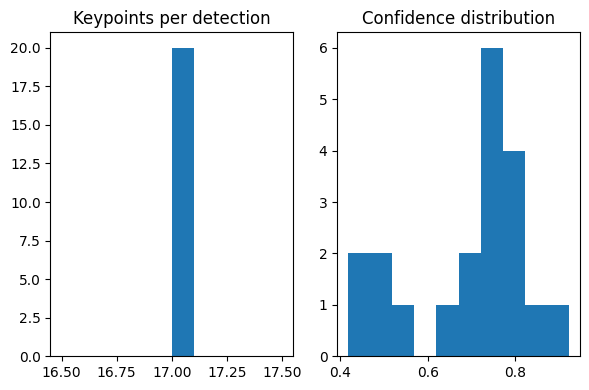

In [20]:
plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
plt.hist(keypoint_counts)
plt.title("Keypoints per detection")

plt.subplot(1,2,2)
plt.hist(confidence_scores)
plt.title("Confidence distribution")

plt.tight_layout()
plt.show()

In [ ]:
import time

start = time.time()

for img in image_files[:50]:
    pose_model.predict(os.path.join(image_folder, img), verbose=False)

end = time.time()

print("Avg inference time per image:", (end-start)/50, "seconds")